<a href="https://colab.research.google.com/github/Laahir/MAT-422/blob/main/MAT422_HW2_Section_2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laahir/MAT-422/blob/main/HW4/MAT422_HW2_Section_2_2.ipynb)

# MAT 422 - Homework 2 - Section 2.2: Probability and Random Variables

**Name:** Laahir
**Course:** MAT 422
**Topics covered:** probability axioms, conditional probability, discrete random variables, continuous random variables

I'm sticking with examples from my job as a Math Instructional Aide again. Studying vs test outcomes, quiz guessing, and exam score distributions all come up in that job pretty naturally, so it felt like the most honest way to demonstrate these ideas instead of picking something abstract.

In [10]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 2.2.1 Probability Axioms

There are three basic rules that any valid probability assignment has to follow:

1. Every event gets a probability that is 0 or bigger, never negative.
2. The probability of the entire sample space (literally everything that could happen) is 1.
3. If two events cannot happen at the same time (they're disjoint), the probability that one or the other happens is just the sum of their individual probabilities.

I'll use a simple sample space here: the outcome of a single die roll, which is one of six equally likely tutoring "difficulty levels" I hand a student, 1 through 6, where 1 is the easiest problem and 6 is the hardest.

In [11]:
outcomes = [1, 2, 3, 4, 5, 6]
probabilities = {outcome: 1/6 for outcome in outcomes}

print("probabilities for each outcome:", probabilities)

# axiom 1: no probability is negative
all_non_negative = all(p >= 0 for p in probabilities.values())
print("axiom 1, every probability is non-negative:", all_non_negative)

# axiom 2: probabilities of the whole sample space add up to 1
total_probability = sum(probabilities.values())
print("axiom 2, total probability =", total_probability)

probabilities for each outcome: {1: 0.16666666666666666, 2: 0.16666666666666666, 3: 0.16666666666666666, 4: 0.16666666666666666, 5: 0.16666666666666666, 6: 0.16666666666666666}
axiom 1, every probability is non-negative: True
axiom 2, total probability = 1.0


In [12]:
# axiom 3: for disjoint events, P(A or B) = P(A) + P(B)
event_A = {1, 2}       # "easy" problems
event_B = {5, 6}       # "hard" problems

p_A = sum(probabilities[x] for x in event_A)
p_B = sum(probabilities[x] for x in event_B)
p_A_or_B_direct = sum(probabilities[x] for x in event_A.union(event_B))
p_A_or_B_by_axiom = p_A + p_B

print("P(A) =", p_A)
print("P(B) =", p_B)
print("P(A union B), counted directly from outcomes =", p_A_or_B_direct)
print("P(A) + P(B), using the disjoint-events rule =", p_A_or_B_by_axiom)
print("do they match?", np.isclose(p_A_or_B_direct, p_A_or_B_by_axiom))

P(A) = 0.3333333333333333
P(B) = 0.3333333333333333
P(A union B), counted directly from outcomes = 0.6666666666666666
P(A) + P(B), using the disjoint-events rule = 0.6666666666666666
do they match? True


Both ways of computing P(A or B) give the same number, and that's the whole point of the third axiom. It only works because A and B don't share any outcomes, if they did overlap, just adding the probabilities would double count the shared part.

## 2.2.2 Conditional Probability

Conditional probability asks: given that we already know something happened, how does that change the chances of something else? The formula is

`P(A | B) = P(A and B) / P(B)`

Here's a table I put together based on a pattern I've genuinely noticed tutoring precalc and calc students: whether a student showed up to office hours before an exam, and whether they passed.

In [13]:
# counts out of 40 students
studied_and_passed = 23
studied_and_failed = 2
no_study_and_passed = 4
no_study_and_failed = 11

total_students = studied_and_passed + studied_and_failed + no_study_and_passed + no_study_and_failed
print("total students =", total_students)

p_studied = (studied_and_passed + studied_and_failed) / total_students
p_passed = (studied_and_passed + no_study_and_passed) / total_students
p_studied_and_passed = studied_and_passed / total_students

print("P(came to office hours) =", p_studied)
print("P(passed) =", p_passed)
print("P(came to office hours AND passed) =", p_studied_and_passed)

total students = 40
P(came to office hours) = 0.625
P(passed) = 0.675
P(came to office hours AND passed) = 0.575


In [14]:
p_passed_given_studied = p_studied_and_passed / p_studied
print("P(passed | came to office hours) =", p_passed_given_studied)

# compare that to the overall pass rate, ignoring whether they came to office hours
print("P(passed), overall =", p_passed)
print("difference =", p_passed_given_studied - p_passed)

P(passed | came to office hours) = 0.9199999999999999
P(passed), overall = 0.675
difference = 0.24499999999999988


The pass rate jumps from about 68% overall to 92% once we condition on coming to office hours. That's the entire idea of conditional probability, knowing extra information (attendance) changes the probability we'd assign to the outcome (passing). It doesn't prove office hours caused the improvement on its own, correlation isn't causation, but it's a clean numeric example of how conditioning shifts a probability.

## 2.2.3 Discrete Random Variables

A discrete random variable takes on a countable set of specific values, each with its own probability. A classic example: a student randomly guessing on a 5-question multiple choice quiz, where each question has 4 choices, so a random guess is right with probability 0.25.

Let X be the number of questions the student gets right out of 5 just by guessing. X can only be 0, 1, 2, 3, 4, or 5, so this is discrete, and it follows a binomial distribution.

In [15]:
n_questions = 5
p_correct = 0.25

X = stats.binom(n_questions, p_correct)
possible_values = np.arange(0, n_questions + 1)
pmf_values = X.pmf(possible_values)

print("possible number of correct guesses:", possible_values)
print("probability of each outcome (the PMF):", pmf_values)
print("do the probabilities sum to 1?", np.isclose(pmf_values.sum(), 1))

possible number of correct guesses: [0 1 2 3 4 5]
probability of each outcome (the PMF): [0.2373 0.3955 0.2637 0.0879 0.0146 0.001 ]
do the probabilities sum to 1? True


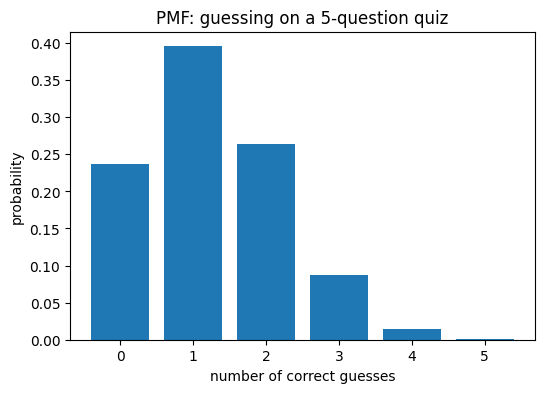

expected number correct just by guessing = 1.25
variance = 0.9375


In [16]:
plt.figure(figsize=(6, 4))
plt.bar(possible_values, pmf_values, color="tab:blue")
plt.xlabel("number of correct guesses")
plt.ylabel("probability")
plt.title("PMF: guessing on a 5-question quiz")
plt.show()

expected_correct = X.mean()
variance_correct = X.var()
print("expected number correct just by guessing =", expected_correct)
print("variance =", variance_correct)

On average, a student who guesses on every question gets 1.25 questions right out of 5, which lines up with the intuitive answer, 5 questions times a 0.25 chance each. The bar chart shows getting exactly 1 question right is the single most likely outcome, and getting all 5 right by pure guessing is extremely unlikely, under 0.1% here.

## 2.2.4 Continuous Random Variables

A continuous random variable can take any value in a range, not just a countable list. Exam scores are a common example when we model them with a bell curve instead of tracking each individual score. Here I'll model a class's exam scores as normally distributed with a mean of 75 and a standard deviation of 8.

For continuous variables we don't ask for the probability of one exact value (that's technically 0), we ask for the probability the value falls in some range, which means integrating the probability density function (PDF) over that range.

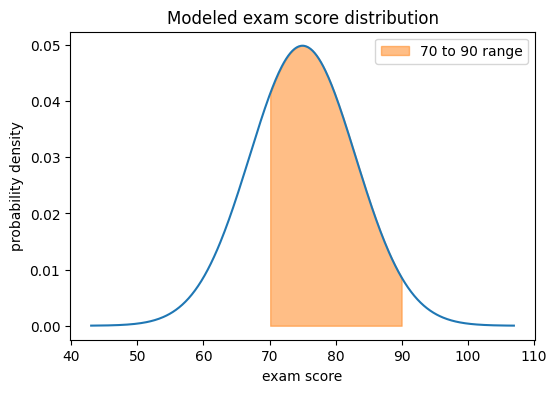

In [17]:
mean_score = 75
std_score = 8

Y = stats.norm(mean_score, std_score)

x_values = np.linspace(mean_score - 4*std_score, mean_score + 4*std_score, 400)
pdf_values = Y.pdf(x_values)

plt.figure(figsize=(6, 4))
plt.plot(x_values, pdf_values, color="tab:blue")
plt.fill_between(x_values, pdf_values, where=(x_values >= 70) & (x_values <= 90),
                  color="tab:orange", alpha=0.5, label="70 to 90 range")
plt.xlabel("exam score")
plt.ylabel("probability density")
plt.title("Modeled exam score distribution")
plt.legend()
plt.show()

In [18]:
# probability a random student scores between 70 and 90, using the CDF
prob_cdf = Y.cdf(90) - Y.cdf(70)
print("P(70 <= score <= 90), from the CDF =", prob_cdf)

# same probability, computed by directly integrating the PDF (numerically)
from scipy.integrate import quad
prob_integral, integration_error = quad(Y.pdf, 70, 90)
print("P(70 <= score <= 90), from integrating the PDF =", prob_integral)
print("do the two methods agree?", np.isclose(prob_cdf, prob_integral))

P(70 <= score <= 90), from the CDF = 0.7036181091860381
P(70 <= score <= 90), from integrating the PDF = 0.7036181091860382
do the two methods agree? True


Both methods land on about 70%, which makes sense, the CDF is literally defined as the integral of the PDF, so computing it directly with `quad` should always match. In plain terms, roughly 70% of students in this modeled class would be expected to score somewhere between 70 and 90, based on the shaded area under the curve above.

## Reflection and Submission Checklist

- I explained each concept in my own words before showing the code.
- I checked my claims numerically instead of just trusting the math (probabilities summing to 1, the disjoint-events rule matching a direct count, the PMF summing to 1, the CDF matching a direct numerical integral).
- I used personal examples tied to my job as a Math Instructional Aide (difficulty levels, office hours attendance vs passing, quiz guessing, exam score distributions) instead of a generic textbook dataset.
- I ran every cell top to bottom in Colab with no errors.
- I saved this notebook directly from Google Colab to GitHub so the Open in Colab badge works.